5、Agent的高级用法1：设置Agent名称
创建Agent时，LangChain允许用户指定其名称

In [1]:
from langchain.chat_models import init_chat_model
from langchain.agents import create_agent
from dotenv import load_dotenv
from rich import print as rprint
import os

load_dotenv(override=True)
DEEPSEEK_API_KEY = os.getenv("DEEPSEEK_API_KEY")
DEEPSEEK_BASE_URL = "https://api.deepseek.com"
model = init_chat_model(
    model="deepseek-v4-flash",
    model_provider="deepseek",
    api_key=DEEPSEEK_API_KEY,
    base_url=DEEPSEEK_BASE_URL,
    extra_body={"thinking": {"type": "disabled"}}  #关闭思考模式
)
agent = create_agent(model, name="agent1")
print(type(agent))

response = agent.invoke({"messages": ["你好"]})
rprint(response)
for msg in response["messages"]:
    msg.pretty_print()


ImportError: module ''langchain_core.runnables'.'config'' not found (No module named 'uuid_utils._uuid_utils')

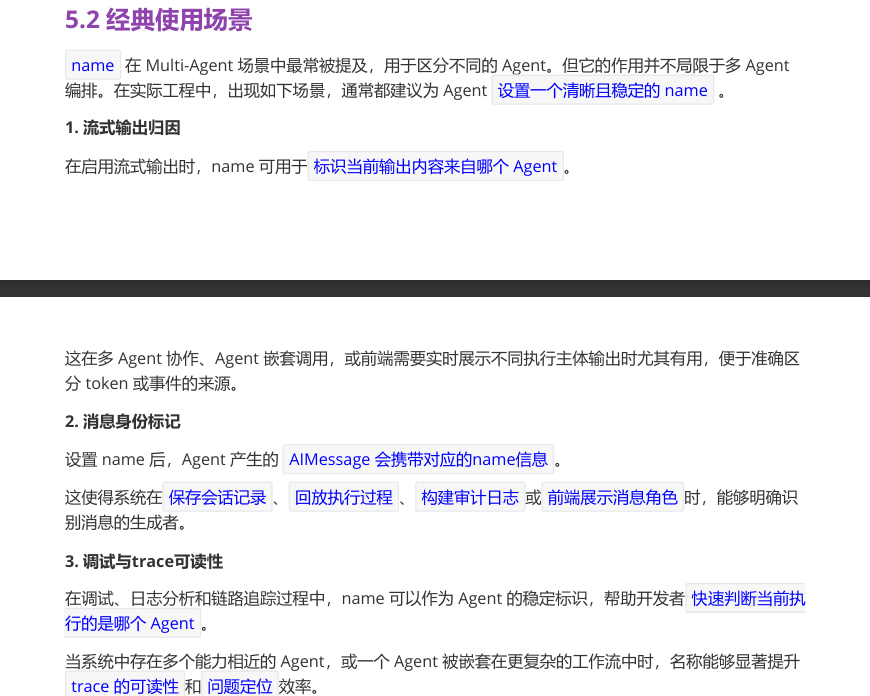
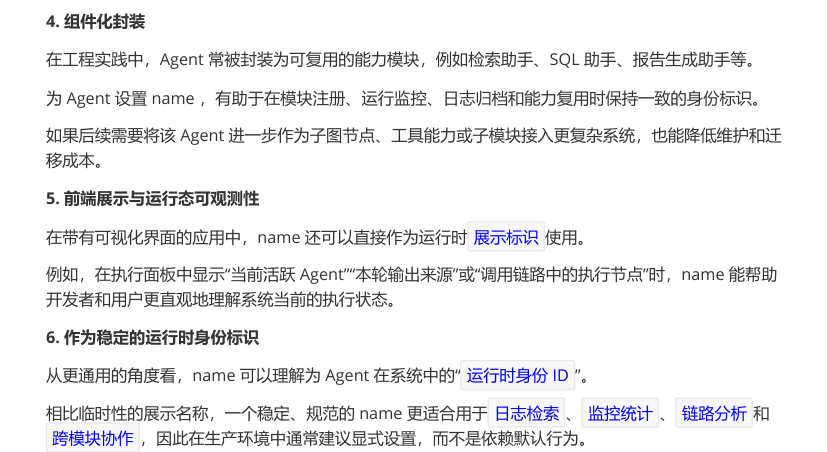

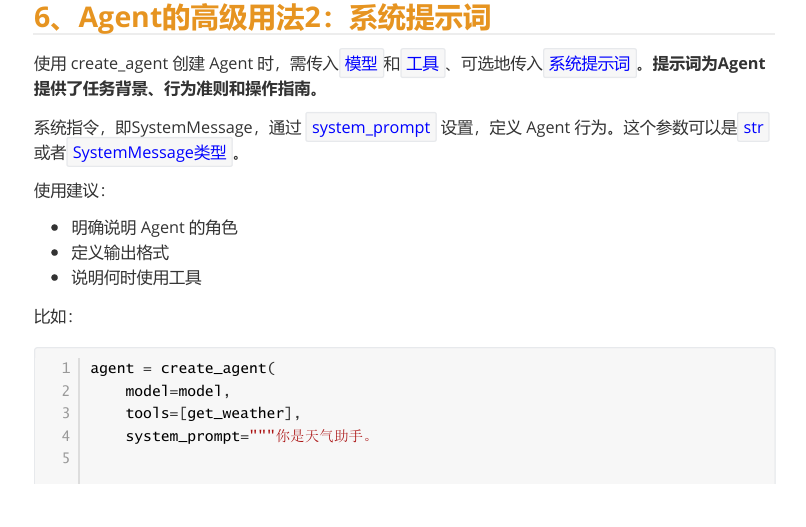
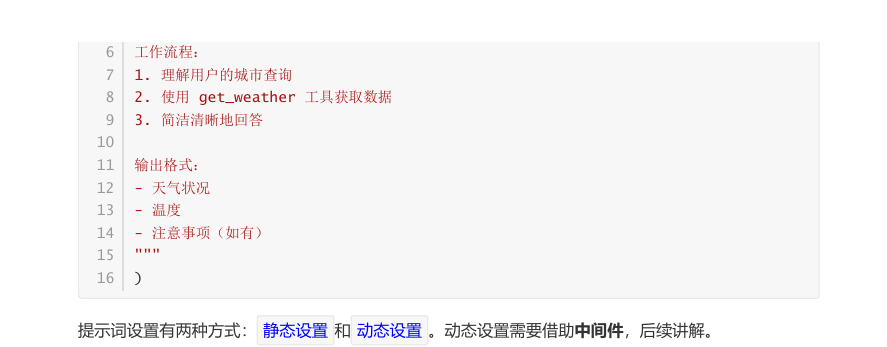

举例1：

In [5]:
from langchain_tavily import TavilySearch
from langchain.agents import create_agent

# 2.导入工具
web_search = TavilySearch(max_results=2)
# 3.创建Agent
agent = create_agent(
    model=model,
    name="agent1",
    tools=[web_search],
    system_prompt="你是一名多才多艺的智能助手，可以调用工具帮助用户解决问题。"
)
# 4.运行Agent获得结果
result = agent.invoke(
    {"messages": [
        {"role": "user", "content": "请帮我查询2026年足球世界杯是哪个国家举办的？"}
    ]}
)
rprint(result)
print(result['messages'][-1].pretty_print())

{
    'messages': [
        HumanMessage(
            content='请帮我查询2026年足球世界杯是哪个国家举办的？',
            additional_kwargs={},
            response_metadata={},
            id='47e36372-10d4-48d3-a716-151fabae046f'
        ),
        AIMessage(
            content='',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 52,
                    'prompt_tokens': 1839,
                    'total_tokens': 1891,
                    'completion_tokens_details': None,
                    'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 1792},
                    'prompt_cache_hit_tokens': 1792,
                    'prompt_cache_miss_tokens': 47
                },
                'model_provider': 'deepseek',
                'model_name': 'deepseek-v4-flash',
                'system_fingerprint': 'fp_8b330d02d0_prod0820_fp8_kvcache_20260402',
                'id': '82a9a138-63c3-4fe0-bd7b-bb1febd1917e',
                'finish_reason': 'tool_calls',
                'logprobs': None
            },
            name='agent1',
            id='lc_run--019f64f3-fb6b-7da0-a938-6351674f4900-0',
            tool_calls=[
                {
                    'name': 'tavily_search',
                    'args': {'query': '2026年足球世界杯 举办国家'},
                    'id': 'call_00_UlTJg3bjIFupjxlj8XRR1966',
                    'type': 'tool_call'
                }
            ],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 1839,
                'output_tokens': 52,
                'total_tokens': 1891,
                'input_token_details': {'cache_read': 1792},
                'output_token_details': {}
            }
        ),
        ToolMessage(
            content='{"query": "2026年足球世界杯 举办国家", "follow_up_questions": null, "answer": null, "images": 
[], "results": [{"url": "https://www.xinhuanet.com/20260509/59361d08fa3644beb6bea55caddf3b30/c.html", "title": 
"2026世界杯美加墨三国将分别举办开幕式", "content": "# 2026世界杯美加墨三国将分别举办开幕式. 2026-05-09 16:50:21  
来源：新华网. 
新华社华盛顿5月8日电（记者杨伶）国际足联8日宣布，2026年世界杯举办国墨西哥、加拿大和美国将分别举办开幕式。. 
图为3月28日拍摄的墨西哥城阿兹特克体育场（无人机照片）。新华社记者 李木子 摄. 
国际足联主席因凡蒂诺表示：“从墨西哥城开始，接下来是多伦多和洛杉矶，这些开幕式将音乐、文化和足球融为一体，既体现了每
个国家的独特性，也展现了本届赛事所代表的团结精神……这将是开启一场全球盛会的有力方式。”. 
美加墨世界杯将于6月11日开幕，揭幕战是墨西哥队对阵南非队，比赛将在墨西哥城举行。国际足联在声明中说，比赛开始前90分钟
，墨西哥将以一场“史无前例的开幕式拉开这场地球上最盛大演出的序幕”。加拿大将于6月12日在多伦多举办开幕式，之后加拿大队
将迎战波黑队。美国将于6月12日在洛杉矶举行开幕式，之后美国队将迎来与巴拉圭队的小组赛。. 
美加墨世界杯将于6月11日至7月19日在美国、加拿大、墨西哥的16座城市举行，这是首次有48支球队参赛的世界杯，比赛场次也大
幅增加至104场。.", "score": 0.8646883, "raw_content": null}, {"url": 
"https://www.aps.dz/cn/sports/sport-collectif/mnfzpl39-2026%E5%B9%B4%E4%B8%96%E7%95%8C%E6%9D%AF48%E6%94%AF%E5%8F%82
%E8%B5%9B%E5%9B%BD%E5%AE%B6", "title": "2026年世界杯48支参赛国家", "content": "# 2026年世界杯48支参赛国家. 
巴黎（法国）——伊拉克于周三获得了2026年世界杯的最后一个参赛资格（6月11日—7月19日），这是首次将参赛队伍扩充至48支，并
由三个国家（美国、加拿大和墨西哥）联合举办的世界杯。.", "score": 0.84027237, "raw_content": null}], 
"response_time": 0.0, "request_id": "ba762f57-856e-47bc-9bbf-c383111c736a"}',
            name='tavily_search',
            id='e397cf7a-fdfd-40d3-9b8b-1b1b7c4aeed6',
            tool_call_id='call_00_UlTJg3bjIFupjxlj8XRR1966'
        ),
        AIMessage(
            content='2026年足球世界杯是由 **美国、加拿大和墨西哥** 
三个国家联合举办的。这是世界杯历史上首次由三个国家共同主办。\n\n以下是关于2026年世界杯的一些关键信息：\n\n- 
**举办国**：美国、加拿大、墨西哥（简称"美加墨世界杯"）\n- **举办时间**：2026年6月11日 - 7月19日\n- 
**参赛队伍**：首次扩军至 **48支球队**，共进行104场比赛\n- **比赛城市**：在三个国家的16座城市举行\n- 
**开幕式**：三个国家将分别举办开幕式（墨西哥城、多伦多、洛杉矶）\n- 
**揭幕战**：墨西哥队对阵南非队，在墨西哥城举行',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 152,
                    'prompt_tokens': 2542,
                    'total_tokens': 2694,
                    'completion_tokens_details': None,
                    'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 2432},
                    'prompt_cache_hit_tokens': 2432,
         

================================== Ai Message ==================================
Name: agent1

2026年足球世界杯是由 **美国、加拿大和墨西哥** 三个国家联合举办的。这是世界杯历史上首次由三个国家共同主办。

以下是关于2026年世界杯的一些关键信息：

- **举办国**：美国、加拿大、墨西哥（简称"美加墨世界杯"）
- **举办时间**：2026年6月11日 - 7月19日
- **参赛队伍**：首次扩军至 **48支球队**，共进行104场比赛
- **比赛城市**：在三个国家的16座城市举行
- **开幕式**：三个国家将分别举办开幕式（墨西哥城、多伦多、洛杉矶）
- **揭幕战**：墨西哥队对阵南非队，在墨西哥城举行
None


举例2：

In [6]:
from langchain.agents import create_agent
from langchain_core.messages import SystemMessage
from langchain_core.tools import tool
from rich import print as rprint


# 工具：实现两数相加
@tool
def add_numbers(a: int, b: int) -> str:
    """计算并返回两个数的和。"""
    return f"和为：{a + b}"


# 创建客服助手Agent
agent = create_agent(
    model=model,
    tools=[add_numbers],  # 工具列表
    # system_prompt="你是一个数学助手，解决日常的算术问题"
    system_prompt=SystemMessage(content="你是一个数学助手，解决日常的算术问题")
)
response = agent.invoke(
    {"messages": [
        {"role": "user", "content": "10加上20再加上30是多少？"}
    ]},
)
rprint(response)
# print(response["messages"][-1].content)

{
    'messages': [
        HumanMessage(
            content='10加上20再加上30是多少？',
            additional_kwargs={},
            response_metadata={},
            id='b25ce3de-82f7-4637-aced-497278e71cf3'
        ),
        AIMessage(
            content='让我来帮你计算：10 + 20 + 30 = ？\n\n先计算 10 + 20：',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 81,
                    'prompt_tokens': 303,
                    'total_tokens': 384,
                    'completion_tokens_details': None,
                    'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 0},
                    'prompt_cache_hit_tokens': 0,
                    'prompt_cache_miss_tokens': 303
                },
                'model_provider': 'deepseek',
                'model_name': 'deepseek-v4-flash',
                'system_fingerprint': 'fp_8b330d02d0_prod0820_fp8_kvcache_20260402',
                'id': '57e2a441-d056-4462-8058-9dd7a3344c01',
                'finish_reason': 'tool_calls',
                'logprobs': None
            },
            id='lc_run--019f64f5-0a48-7a83-b5bb-fdd9c866e928-0',
            tool_calls=[
                {
                    'name': 'add_numbers',
                    'args': {'a': 10, 'b': 20},
                    'id': 'call_00_y4aVCi57PVsgbfu6hWYO7051',
                    'type': 'tool_call'
                }
            ],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 303,
                'output_tokens': 81,
                'total_tokens': 384,
                'input_token_details': {'cache_read': 0},
                'output_token_details': {}
            }
        ),
        ToolMessage(
            content='和为：30',
            name='add_numbers',
            id='b20c61ba-13fc-45a4-9f41-05a8f05c7bd5',
            tool_call_id='call_00_y4aVCi57PVsgbfu6hWYO7051'
        ),
        AIMessage(
            content='结果是 30，然后再加 30：',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 67,
                    'prompt_tokens': 399,
                    'total_tokens': 466,
                    'completion_tokens_details': None,
                    'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 384},
                    'prompt_cache_hit_tokens': 384,
                    'prompt_cache_miss_tokens': 15
                },
                'model_provider': 'deepseek',
                'model_name': 'deepseek-v4-flash',
                'system_fingerprint': 'fp_8b330d02d0_prod0820_fp8_kvcache_20260402',
                'id': 'c141aa39-a4f5-4cb9-9f97-1d40050823da',
                'finish_reason': 'tool_calls',
                'logprobs': None
            },
            id='lc_run--019f64f5-0f5d-7a21-bd4c-c3cb1fa6002d-0',
            tool_calls=[
                {
                    'name': 'add_numbers',
                    'args': {'a': 30, 'b': 30},
                    'id': 'call_00_8iyORWtv5lwkUOx2GLKf2270',
                    'type': 'tool_call'
                }
            ],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 399,
                'output_tokens': 67,
                'total_tokens': 466,
                'input_token_details': {'cache_read': 384},
                'output_token_details': {}
            }
        ),
        ToolMessage(
            content='和为：60',
            name='add_numbers',
            id='45ed39c3-f1c4-41ec-8cfc-8cc2f3ded603',
            tool_call_id='call_00_8iyORWtv5lwkUOx2GLKf2270'
        ),
        AIMessage(
            content='最终结果是 **60**！🍎\n\n计算步骤：\n- 10 + 20 = 30\n- 30 + 30 = 60\n\n所以 10 加上 20 再加上 
30 等于 **60**。',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                

举例3：

In [ ]:
from langchain.agents import create_agent
from langchain.tools import tool
from langchain.messages import SystemMessage, HumanMessage

flag = 0


@tool
def get_weather(city: str):
    """
    天气查询工具
    Args:
        city: 城市名称
    """
    global flag
    flag += 1
    if flag < 3:
        # raise Exception("暂时无法访问")
        return "TEMP_UNAVAILABLE: 天气服务暂时不可用，请稍后重试"
    return f"{city}今天天气挺好"


messages = [
    HumanMessage("你好，杭州今天的天气如何？")
]
agent = create_agent(
    model=model,
    tools=[get_weather],
    system_prompt=SystemMessage(
        "你是一个天气助手。"
        "当工具返回以 'TEMP_UNAVAILABLE:' 开头的结果时，"
        "说明是临时故障，不要立即放弃；"
        "你应再次调用同一个工具，最多重试 3 次。"
        "如果 3 次后仍失败，再向用户说明服务暂时不可用。"
    )
)
response = agent.invoke({"messages": messages})
# print(response)
for msg in response["messages"]:
    msg.pretty_print()

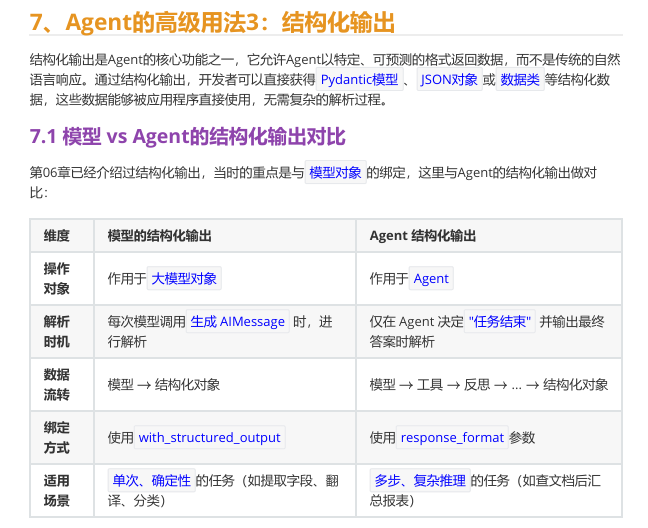


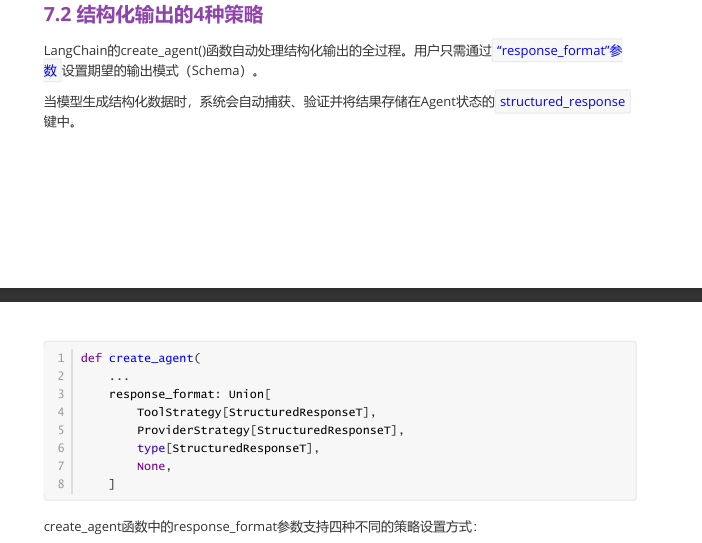


1. ProviderStrategy
使用模型提供商的
原生结构化输出功能实现结构化输出。
这里所说的“原生结构化输出”指的是大语言模型（LLM）提供商通过其API直接提供的、在模型响应
阶段就强制保证
输出格式符合预定规范的能力，这种能力能够在模型生成内容的源头确保结构化
准确性。
适用于支持原生结构化输出的模型，比如OpenAI、Anthropic Claude或xAI Grok等

In [3]:
from pydantic import BaseModel, Field
from langchain.agents import create_agent
from langchain.agents.structured_output import ProviderStrategy
from langchain.messages import HumanMessage
from rich import print as rprint


# 2.Pydantic结构化方式定义
class ContactInfo(BaseModel):
    """用户的联系方式"""
    name: str = Field(description="用户姓名")
    email: str = Field(description="用户邮箱地址")
    phone: str = Field(description="用户的手机号")


# 3.agent初始化
agent = create_agent(
    model=model,
    response_format=ProviderStrategy(ContactInfo)
)
# 4.调用
response = agent.invoke({
    "messages": [
        HumanMessage("从这段话中抽取结构化信息：小明的邮箱地址为：shkstart @ atguigu.com，手机号：12345678912")
    ]
}
)
# rprint(response)
for msg in response["messages"]:
    msg.pretty_print()

BadRequestError: Error code: 400 - {'error': {'message': 'This response_format type is unavailable now', 'type': 'invalid_request_error', 'param': None, 'code': 'invalid_request_error'}}

DEEPSEEK模型不支持这种结构化输出的响应模式，会报错。

② ToolStrategy
对于不支持原生结构化输出的模型，LangChain采用“ToolStrategy”工具调用的方式实现结构化输出。
此策略兼容绝大多数
支持工具调用的现代模型，其核心原理是动态创建一个"
入参数对应着期望的数据结构。
当模型需要生成最终答案时，系统会引导模型
虚拟工具"，该工具的输
"调用"这个虚拟工具 ，从而间接产生符合要求的结构化数
据。
举例：

In [6]:
from pydantic import BaseModel
from langchain.agents import create_agent
from langchain.agents.structured_output import ToolStrategy
from langchain_core.tools import tool


# 2.Pydantic结构化方式定义
class ContactInfo(BaseModel):
    name: str = Field(description="姓名")
    email: str = Field(description="邮箱")
    phone: str = Field(description="电话")


# 3.工具的定义（根据需要定义）
@tool
def search_tool(query: str) -> str:
    """
    这是一个搜索引擎。当大模型发现给定的上下文里缺少必要的联系人信息，
    需要去互联网上查询时，才会调用这个工具。
    """
    return f"搜索结果: 未找到关于 '{query}' 的更多额外信息。"


# 3.agent初始化
agent = create_agent(
    model=model,
    tools=[search_tool],
    response_format=ToolStrategy(ContactInfo)
)
result = agent.invoke({
    "messages": [{"role": "user", "content": "联系人信息: John Doe, john@atguigu.com, (010) 56253825"}]
})
# print(result)
print(result["structured_response"])

name='John Doe' email='john@atguigu.com' phone='(010) 56253825'


③ type / AutoStrategy
官方没有在参数列表或官方文档列出这种策略，但阅读源码可以看到。

In [ ]:
ResponseFormat = ToolStrategy[SchemaT] | ProviderStrategy[SchemaT] |
AutoStrategy[SchemaT]
"""Union type for all supported response format strategies."""

当我们直接传入一个定义类型时，LangChain会自动包装为AutoStrategy，触发自动选择策略：如果
模型支持原生结构化输出（如OpenAI、Anthropic Claude或xAI Grok），则优先使用
ProviderStrategy；否则使用ToolStrategy。
举例1：

In [7]:
from langchain.agents.structured_output import AutoStrategy
from pydantic import BaseModel, Field
from langchain.agents import create_agent


class ContactInfo(BaseModel):
    """联系人信息"""
    name: str = Field(description="姓名")
    email: str = Field(description="邮箱")
    phone: str = Field(description="电话")


agent = create_agent(
    model=model,
    response_format=AutoStrategy(ContactInfo))

result = agent.invoke({
    "messages": [{"role": "user", "content": "联系人信息: John Doe, john@atguigu.com, (010) 56253825"}]
})
# print(result)
print(result["structured_response"])

name='John Doe' email='john@atguigu.com' phone='(010) 56253825'


特别注意：在LangChain 1.0及以上版本中，直接传递模式（如response_format=ContactInfo）不再支
持，必须显式使用ToolStrategy或ProviderStrategy。（经过测试，目前LangChain 1.2版本还可使用）。
举例2：

In [8]:
from pydantic import BaseModel, Field
from langchain.agents import create_agent
class ContactInfo(BaseModel):
    """联系人信息"""
    name: str = Field(description="姓名")
    email: str = Field(description="邮箱")
    phone: str = Field(description="电话")
agent = create_agent(
    model=model,
    response_format=ContactInfo  # Auto-selects ProviderStrategy
)
result = agent.invoke({
    "messages": [{"role": "user", "content": "联系人信息: John Doe, john@atguigu.com, (010) 56253825"}]
})
# print(result)
print(result["structured_response"])

name='John Doe' email='john@atguigu.com' phone='(010) 56253825'


④ None
默认配置，表示不以结构化输出，以自然语言响应用户问题。
总结：
在实际大模型Agent开发场景中，如果使用到了结构化输出，推荐使用“ToolStrategy”策略，所以后续
重点介绍这种策略方式结构化输出。
